### Zadanie 1.
W wybranymśrodowisku napisz program do wyznaczania następujących statystyk dla danego wektora
obserwacji: mediana, kwartyle, rozstęp z próby, rozstęp międzykwartylowy, wariancja z próby oraz
odchylenie standardowe. Wyznacz wartości powyższych charakterystyk dla wysymulowanej próby z
rozkładu normalnego z parametrami µ = 2 i σ = 2 o długości 2000 elementów. Otrzymane wyniki
porównaj z wynikami uzyskanymi za pomocą funkcji wbudowanych.

In [65]:
import numpy as np
import scipy.stats as sc

In [66]:
def median(T):
    T = np.sort(T)
    n = len(T)
    if n % 2 == 1:
        return T[n // 2]
    else:
        return 0.5 * (T[n // 2] + T[n // 2 - 1])
    
def quartile(T):
    T = np.sort(T)
    n = len(T)
    q1 = median(T[:n // 2])
    q2 = median(T)
    q3 = median(T[n // 2:])
    q4 = T[n - 1]
    return [q1, q2, q3, q4]

def range2(T):
    return max(T) - min(T)

def IQR(T):
    a, _, b, _ = quartile(T)
    return b - a

def Var(T):
    n = len(T)
    mean = median(T)
    a = (T - mean)**2
    var = np.sum(a)
    var /= (n - 1)
    return var

mi = 2
sigma = 2
size = 2000

X = np.random.normal(2, 2, 2000)
print(X)
print(quartile(X))

[ 3.99290198  1.84189176  1.99128893 ...  1.98530807 -0.90602664
  1.07809813]
[np.float64(0.6718733390960028), np.float64(2.08498396243219), np.float64(3.4123966138913064), np.float64(7.9686890469305345)]


### Zadanie 2
Na stronie internetowej https://vincentarelbundock.github.io/Rdatasets/datasets.html znajdź dowol
ne dane o co najmniej 1000 obserwacjach. Dla tych danych wyznacz średnią arytmetyczną, harmo
niczną oraz geometryczną. Ponadto przedstaw wykres średniej ucinanej i winsorowskiej jako funkcję
parametru k

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv(r'https://vincentarelbundock.github.io/Rdatasets/csv/AER/CPSSWEducation.csv')


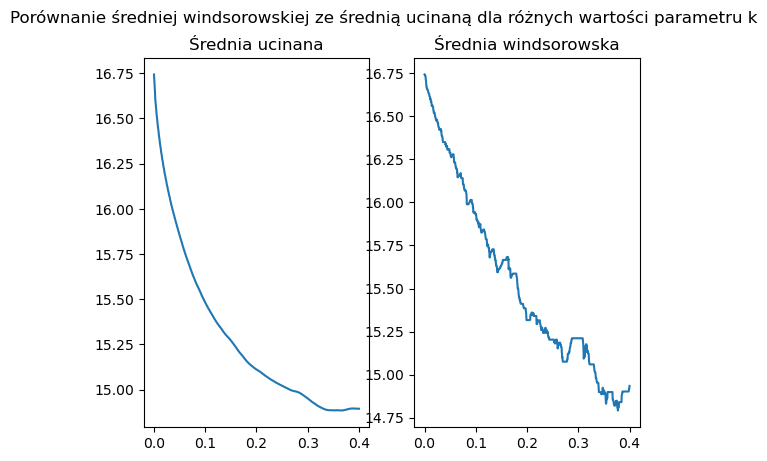

[np.float64(14.682594621467368),
 np.float64(12.81726630571915),
 np.float64(16.742717344030506)]

In [68]:
def z2():
    finance = data['earnings']
    g_mean = sc.gmean(finance)
    h_mean = sc.hmean(finance)
    a_mean = np.mean(finance)
    k = np.linspace(0, 0.4, 1000)
    t_mean = []
    w_mean = []
    for i in k:
        t_mean.append(sc.trim_mean(finance, i))
        w = sc.mstats.winsorize(finance, limits=i)
        w_mean.append(np.mean(w))

    fig, axs = plt.subplots(1, 2)
    fig.suptitle('Porównanie średniej windsorowskiej ze średnią ucinaną dla różnych wartości parametru k')
    axs[0].plot(k, t_mean)
    axs[0].set_title('Średnia ucinana')
    axs[1].plot(k, w_mean)
    axs[1].set_title('Średnia windsorowska')
    plt.show()
    return [g_mean, h_mean, a_mean]

z2()

0       30
1       30
2       30
3       30
4       30
        ..
2945    30
2946    30
2947    29
2948    29
2949    30
Name: age, Length: 2950, dtype: int64


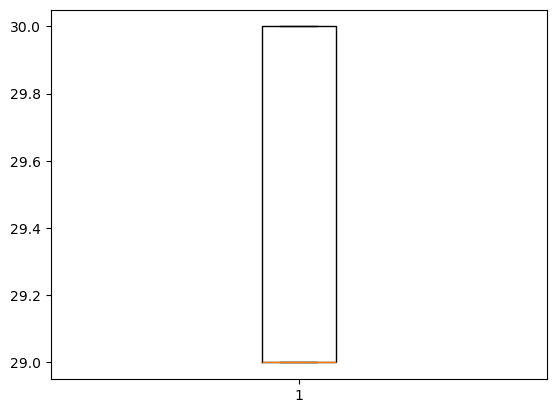

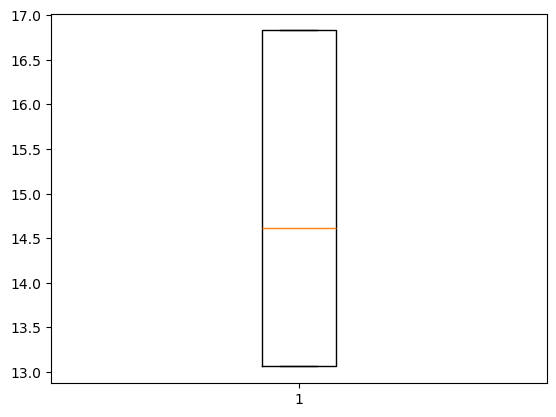

In [69]:
def z3():
    year = data['age']
    plt.boxplot(year)
    print(year)
    plt.show()
    finance = data['earnings']
    plt.boxplot(finance)
    plt.show()

z3()

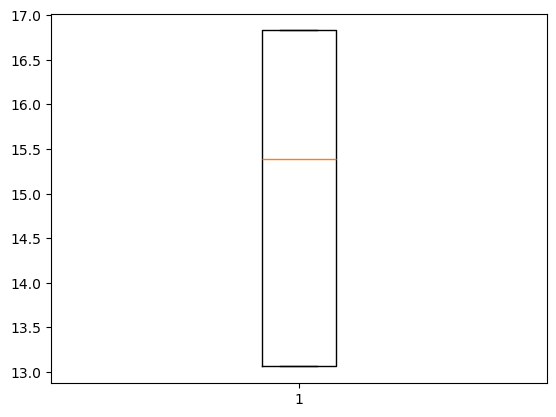

<Axes: xlabel='earnings', ylabel='Count'>

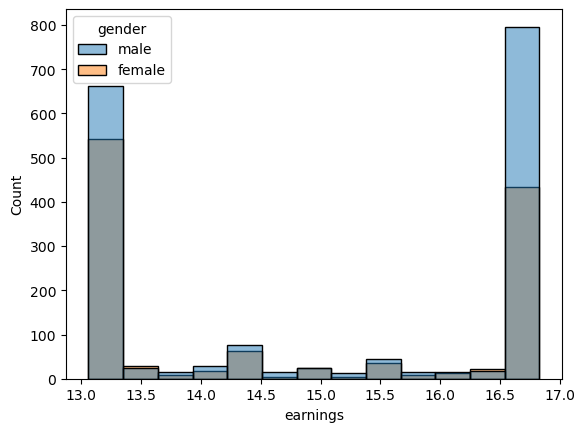

In [70]:
male_data = data.loc[data['gender'] == 'male', 'earnings']
plt.boxplot(male_data)
plt.show()

import seaborn as sns
sns.histplot(data=data,x='earnings',hue='gender')
#sns.boxplot(data=data, x='earnings',y='gender') # wyświetl dane 

Średnia: 10.144488701213652
Mediana: 10.009672388074037
IQR: 6.7127332919993705
Variance: 26.854251326830138
Sigma: 5.182108772192083
Kurtoza: 3.1767390558309434
Kurtoza: 0.1314766237232393


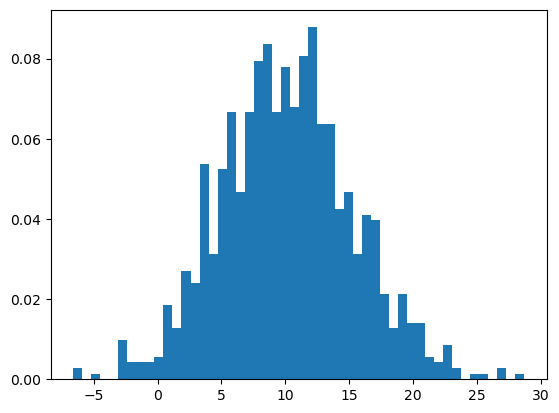

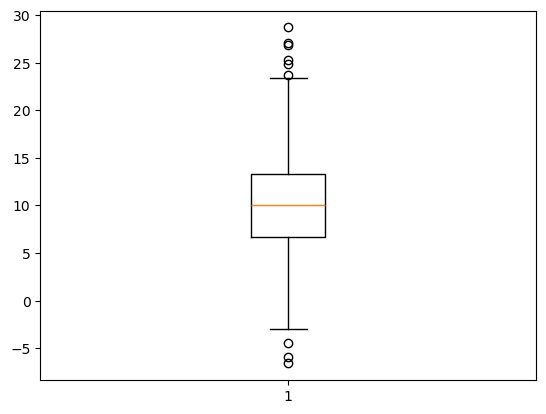

Średnia: 10.775871515999194
Mediana: 10.05711008161067
IQR: 6.817107293671199
Variance: 69.01566673699728
Sigma: 8.307566836143858
Kurtoza: 45.033998796865504
Kurtoza: 5.036463032541154


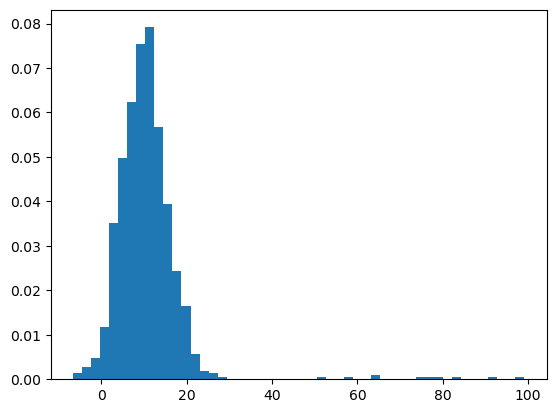

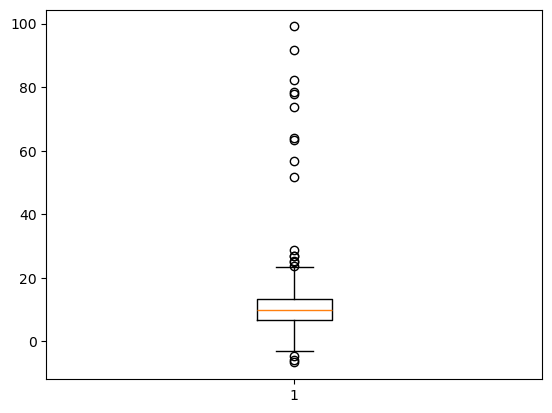

In [71]:
def show_statistics(X):
    print(f'Średnia: {np.mean(X)}')
    print(f'Mediana: {np.median(X)}')
    print(f'IQR: {IQR(X)}')
    print(f'Variance: {Var(X)}')
    print(f'Sigma: {np.sqrt(Var(X))}')
    print(f'Kurtoza: {sc.kurtosis(X, bias=False, fisher=False)}')
    print(f'Kurtoza: {sc.skew(X, bias=False)}')
    x = np.linspace(5, 100, num=len(X))
    plt.hist(X, bins=50, density=True)
    plt.show()
    plt.boxplot(X)
    plt.show()

X = np.random.normal(10, 5, size=1000)
U = np.random.uniform(low=50, high=100, size=10)

show_statistics(X)
X2 = []
for x in X:
    X2.append(x)
for u in U:
    X2.append(u)


    
show_statistics(X2)


Średnia: 10.144488701213652
Mediana: 10.009672388074037
IQR: 6.7127332919993705
Variance: 26.854251326830138
Sigma: 5.182108772192083
Kurtoza: 3.1767390558309434
Kurtoza: 0.1314766237232393


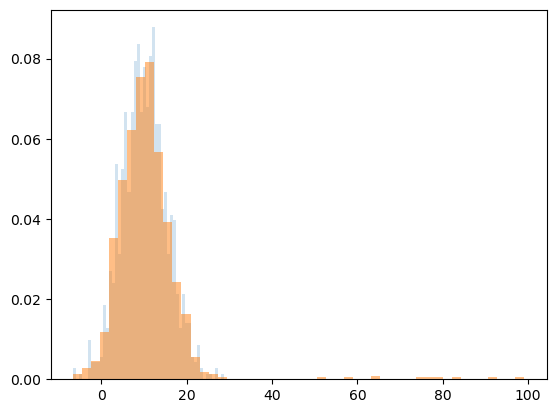

{'whiskers': [<matplotlib.lines.Line2D at 0x1b320abccd0>,
 'caps': [<matplotlib.lines.Line2D at 0x1b320abcf50>,
 'boxes': [<matplotlib.lines.Line2D at 0x1b320abcb90>],
 'medians': [<matplotlib.lines.Line2D at 0x1b320abd1d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1b320abd310>],
 'means': []}

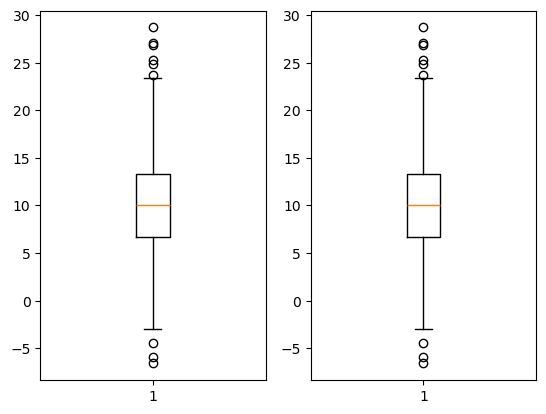

In [72]:
print(f'Średnia: {np.mean(X)}')
print(f'Mediana: {np.median(X)}')
print(f'IQR: {IQR(X)}')
print(f'Variance: {Var(X)}')
print(f'Sigma: {np.sqrt(Var(X))}')
print(f'Kurtoza: {sc.kurtosis(X, bias=False, fisher=False)}')
print(f'Kurtoza: {sc.skew(X, bias=False)}')
x = np.linspace(5, 100, num=len(X))
plt.hist(X, bins=50, density=True, alpha=0.2)
plt.hist(X2, bins=50, density=True, alpha=0.5)
plt.show()

plt.subplot(1, 2, 1)
plt.boxplot(X)
plt.subplot(1,2,2)
plt.boxplot(X)

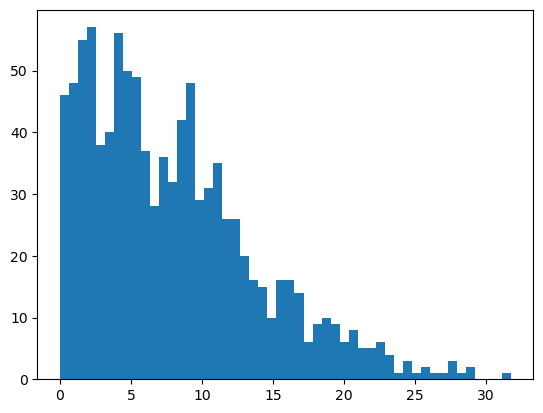

7.982838471984501
7.982838471984501


In [73]:
mi_n = 4
var_n = 10
X = np.random.normal(mi_n, var_n, size=1000)
EX = np.mean(X)
Y = abs(X - EX)
plt.hist(Y, bins=50)
plt.show()
EY = np.mean(Y)
y = []

for i in range(1000):
    X = np.random.normal(mi_n, var_n, size=1000)
    EX = np.mean(X)
    Y = abs(X - EX)
    EY = np.mean(Y)
    y.append(EY)

print(np.mean(y))

def f1(n):
    for i in range(n):
        X = np.random.normal(mi_n, var_n, size=1000)
        EX = np.mean(X)
        Y = abs(X - EX)
        EY = np.mean(Y)
        y.append(EY)
    return np.mean(y)


print(np.mean(y))

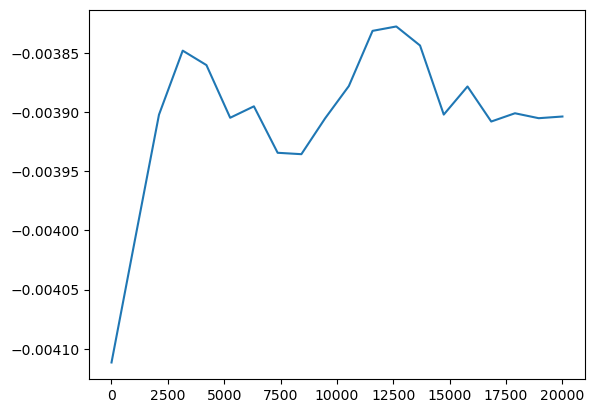

In [77]:
import math

yy = []

M = 20000
for k in range(1, M, 1000):
    #print(k)
    yk = f1(M - k)
    t = np.sqrt(2) * var_n / np.sqrt(math.pi)
    yy.append(yk - t)

x = np.linspace(1, M, len(yy))

plt.plot(x, yy)
plt.show()